In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# Load data
df = pd.read_csv("data.csv")
df.head()

# Preparing data for training
df = df.drop("CustomerID", axis=1)

# One-hot encoding categorical columns (like Gender, Subscription Type, etc.)
df = pd.get_dummies(df, drop_first=True)
df.head()

# Splitting data into Features (X) and Target (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Split into Training and Testing Sets
# stratify=y ensures the same churn distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build Random Forest model
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
# n_estimators=200 → 200 decision trees
# max_depth=10 → Trees are not deeper than 10 levels

# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)  # CORRECT: true order is (y_true, y_pred)
csr = classification_report(y_test, y_pred)  # CORRECT: true order is (y_true, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", csr)
joblib.dump(model,"churn_predction.pkl")
joblib.dump

Accuracy: 0.9976699029126214

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



<function joblib.numpy_pickle.dump(value, filename, compress=0, protocol=None, cache_size=None)>

In [ ]:
import pandas as pd

# Get the feature importances from the model
importances = model.feature_importances_

# Create a DataFrame for better visualization
feature_importance = pd.DataFrame({
    'Feature': X.columns,  # Column names
    'Importance': importances  # Corresponding importances
})

# Now, sort values by importance in descending order
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display the DataFrame
feature_importance

#


,Feature,Importance
4,Payment Delay,0.467690
3,Support Calls,0.166307
1,Tenure,0.103064
2,Usage Frequency,0.079983
7,Gender_Male,0.075253
5,Total Spend,0.038789
0,Age,0.034246
10,Contract Length_Monthly,0.023261
11,Contract Length_Quarterly,0.005893
6,Last Interaction,0.003813


C:\Users\HTC\AppData\Local\Temp\ipykernel_4708\1894021055.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


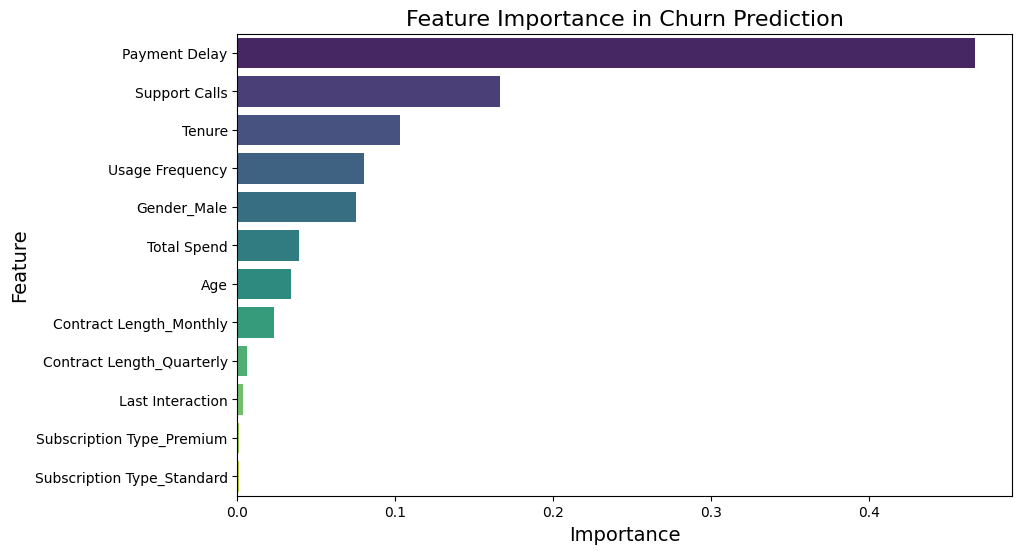

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance in Churn Prediction', fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.show()
